# 1. SVC

In [57]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_moons  
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, classification_report 


In [58]:
# Generate moon dataset
X, y = make_moons(n_samples=200, random_state=0, shuffle=True)

# Split the dataset into training and testing sets
X_train, X_test = X[:100], X[100:]
y_train, y_test = y[:100], y[100:]


In [59]:
class CustomSVC:
    def __init__(self, kernel='rbf', C=1.0, gamma='scale', degree=3):
        self.kernel = kernel
        self.C = C
        self.gamma = gamma
        self.degree = degree
        self.model = None

    def fit(self, X, y):
        self.model = SVC(kernel=self.kernel, C=self.C, gamma=self.gamma, degree=self.degree)
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)



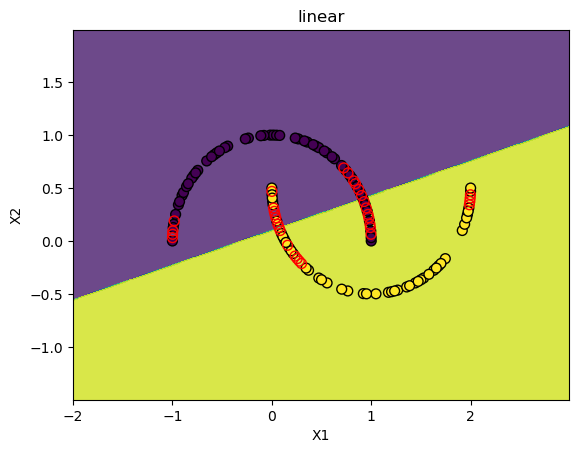

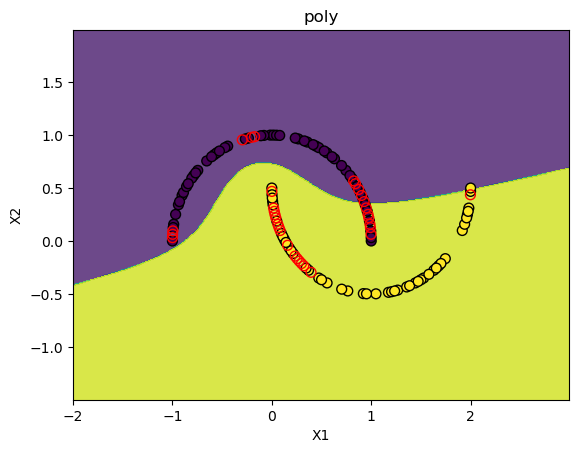

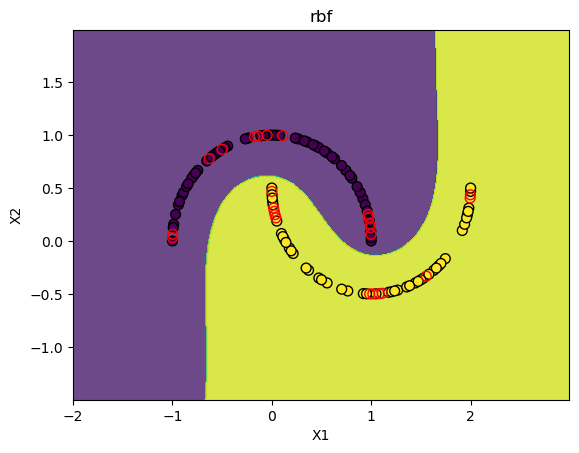

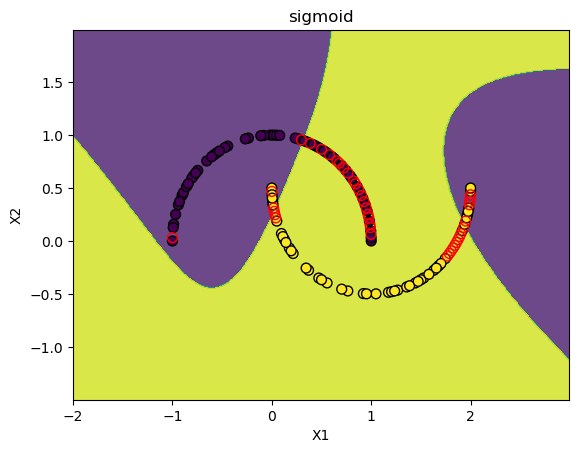

In [60]:
# Create an instance of CustomSVC with different kernel options
kernels = ['linear', 'poly', 'rbf', 'sigmoid' ] 

# Plotting decision boundary
def plot_decision_boundary(model, X, y, kernel):
    h = 0.01
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolors='black')
    plt.scatter(
    model.model.support_vectors_[:, 0], 
    model.model.support_vectors_[:, 1], 
    s=50, facecolors='none', edgecolors='red' )
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title(kernel)
    plt.show()

# Plot decision boundaries for each kernel
for kernel in kernels:
    model = CustomSVC(kernel=kernel)
    model.fit(X_train, y_train)
    plot_decision_boundary(model, X_test, y_test, kernel)


The linear kernel assumes a linear decision boundary. It works well when the data is linearly separable and the decision boundary will be a straight line. On the other hand the polynomial kernel allows for more flexible decision boundaries by using higher-degree polynomials. A higher degree can capture more complex patterns in the data but may also lead to overfitting. <br>

The sigmoid kernel is based on the sigmoid function and can handle non-linear decision boundaries. due to its sensitivity to the choice of hyperparameters it is less commonly used compared to the other kernels.<br>

The moon dataset is not linearly separable; it requires a non-linear decision boundary to accurately separate the two moon shapes. The 'rbf' kernel is well-suited for capturing non-linear relationships in the data. It can create complex decision boundaries by mapping the data points to a higher-dimensional space using a Gaussian function. Therefore in this case rbf perfomed the best. <br>

# 2. Model Evaluation

In [61]:
# Load the dataset
data = pd.read_csv('breast-cancer.csv')

data.head() 

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [62]:
data.shape 

(569, 32)

In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [64]:
# Separate features and target variable
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

# Perform feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check the skewness of the features 
Xscaled = pd.DataFrame(X_scaled)
Xscaled.skew() 


0     6.473752
1     0.942380
2     0.650450
3     0.990650
4     1.645732
5     0.456324
6     1.190123
7     1.401180
8     1.171180
9     0.725609
10    1.304489
11    3.088612
12    1.646444
13    3.443615
14    5.447186
15    2.314450
16    1.902221
17    5.110463
18    1.444678
19    2.195133
20    3.923969
21    1.103115
22    0.498321
23    1.128164
24    1.859373
25    0.415426
26    1.473555
27    1.150237
28    0.492616
29    1.433928
30    1.662579
dtype: float64

the positive skewness values indicate a right-skewed distribution. it means the majority of the data is concentrated on the left side of the distribution, and the tail extends towards the right.  


In [65]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=0) 

In [66]:
# Model 1: Logistic Regression with default hyperparameters
lr_model_1 = LogisticRegression()
lr_model_1.fit(X_train, y_train)

# Model 2: Logistic Regression with different C value
lr_model_2 = LogisticRegression(C=0.1)
lr_model_2.fit(X_train, y_train)

# Model 3: Logistic Regression with different regularization penalty (L1)
lr_model_3 = LogisticRegression(penalty='l1', solver='liblinear')
lr_model_3.fit(X_train, y_train)


LogisticRegression(penalty='l1', solver='liblinear')

In [67]:
# Model 4: SVM with default hyperparameters
svm_model_1 = SVC()
svm_model_1.fit(X_train, y_train)

# Model 5: SVM with different C value and linear kernel
svm_model_2 = SVC(C=0.1, kernel='linear')
svm_model_2.fit(X_train, y_train)

# Model 6: SVM with different gamma value and RBF kernel
svm_model_3 = SVC(gamma=0.1, kernel='rbf')
svm_model_3.fit(X_train, y_train)


SVC(gamma=0.1)

In [68]:
# Create a list of models
models = [lr_model_1, lr_model_2, lr_model_3, svm_model_1, svm_model_2, svm_model_3]

# Evaluate each model
for model in models:
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred) 
    print("Model:", model)
    print("Accuracy:", accuracy)
    print("Classification Report:")
    print(report)
    print("------------------------------")


Model: LogisticRegression()
Accuracy: 0.9649122807017544
Classification Report:
              precision    recall  f1-score   support

           B       0.97      0.97      0.97        67
           M       0.96      0.96      0.96        47

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

------------------------------
Model: LogisticRegression(C=0.1)
Accuracy: 0.9649122807017544
Classification Report:
              precision    recall  f1-score   support

           B       0.96      0.99      0.97        67
           M       0.98      0.94      0.96        47

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

------------------------------
Model: LogisticRegression(penalty='l1', solver='liblinear')
Accuracy: 0.956140350877193
Classification Report:
        

Accuracy: It measures the overall correctness of the model's predictions. Higher accuracy indicates that the model is making correct predictions more often.

Precision: It is the ratio of true positives to the sum of true positives and false positives. In the context of breast cancer diagnosis, precision represents the ability of the model to correctly identify malignant cases (M). Higher precision indicates fewer false positives, which means the model is correctly identifying actual positive cases.

Recall: It is the ratio of true positives to the sum of true positives and false negatives. In the context of breast cancer diagnosis, recall represents the ability of the model to correctly identify all actual positive cases. Higher recall indicates fewer false negatives, which means the model is correctly capturing most positive cases.

F1-score: It provides a balanced measure that considers both precision and recall. Higher F1-score indicates a better balance between precision and recall.

 In the case of breast cancer diagnosis, the focus is often on minimizing false negatives (missing actual positive cases). Therefore, we would prioritize models with higher recall values while maintaining a reasonable level of precision. Among the evaluated models, SVC with default parameters (Model: SVC()) achieved the highest recall for the (M) class while maintaining a high overall accuracy.

This assignment has been done with help of Samaneh Shahpouri